# Phase 3 : BERT Fine-Tuning
### Sentiment Analysis on IMDB Movie Reviews

**Goal:** Fine-tune `bert-base-uncased` for binary sentiment classification and compare it against the BiLSTM from Phase 2.

**Architecture:**
```
Input text → BertTokenizer → bert-base-uncased → [CLS] token → Dropout → Linear → Sigmoid
```

**Key difference from LSTM:**
- BERT is *pretrained* on 3.3B words — we're just adapting it, not teaching it language from scratch
- Uses WordPiece tokenization instead of simple word splitting
- Captures bidirectional context across the *entire* sequence via self-attention

---

## 0. Imports & Config

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizer,
    BertModel,
    get_linear_schedule_with_warmup
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

# ─── Config ───────────────────────────────────────────────────────────────────
CONFIG = {
    'model_name'  : 'bert-base-uncased',
    'max_len'     : 256,    # BERT max is 512 but 256 covers most reviews & saves memory
    'batch_size'  : 16,     # keep small — BERT is memory-heavy
    'epochs'      : 3,      # 2-3 epochs is standard for BERT fine-tuning
    'lr'          : 2e-5,   # small LR crucial — too high destroys pretrained weights
    'warmup_ratio': 0.1,    # 10% of steps used for LR warmup
    'dropout'     : 0.3,
    'seed'        : 42,
}

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])

print(f'✅ Using device: {DEVICE}')
if DEVICE.type == 'cpu':
    print('Running on CPU — each epoch will take ~30-60 mins.')
    print('Tip: Use Google Colab (free GPU) if this is too slow.')
else:
    print('GPU detected — each epoch ~5-10 mins.')

✅ Using device: cpu
Running on CPU — each epoch will take ~30-60 mins.
Tip: Use Google Colab (free GPU) if this is too slow.


---
## 1. Load Cleaned Data

In [4]:
train_df = pd.read_csv('train_clean.csv')
test_df  = pd.read_csv('test_clean.csv')

train_df.dropna(subset=['clean_text'], inplace=True)
test_df.dropna(subset=['clean_text'],  inplace=True)

# Using a subset for CPU training
train_df = train_df.sample(5000, random_state=42).reset_index(drop=True)
test_df  = test_df.sample(1000,  random_state=42).reset_index(drop=True)

print(f'Train: {len(train_df):,} | Test: {len(test_df):,}')
train_df.head(3)

Train: 5,000 | Test: 1,000


,clean_text,label,sentiment
0,dumb is as dumb does in this thoroughly uninte...,0,Negative
1,i dug out from my garage some old musicals and...,1,Positive
2,after watching this movie i was honestly disap...,0,Negative


---
## 2. BERT Tokenizer

> **Why a different tokenizer?**  
> BERT uses WordPiece tokenization — it splits unknown words into subword units (e.g. `"playing"` → `["play", "##ing"]`). This is more robust than simple word splitting and handles rare/misspelled words gracefully.

In [7]:
tokenizer = BertTokenizer.from_pretrained(CONFIG['model_name'])

# Visualise what BERT tokenization looks like
sample = "This movie was absolutely brilliant! Couldn't have asked for more."
tokens = tokenizer.tokenize(sample)
print(f'Original : {sample}')
print(f'Tokenized: {tokens}')
print(f'Token IDs: {tokenizer.convert_tokens_to_ids(tokens)}')
print(f'\n[CLS]=101, [SEP]=102, [PAD]=0 are special tokens added automatically')

Original : This movie was absolutely brilliant! Couldn't have asked for more.
Tokenized: ['this', 'movie', 'was', 'absolutely', 'brilliant', '!', 'couldn', "'", 't', 'have', 'asked', 'for', 'more', '.']
Token IDs: [2023, 3185, 2001, 7078, 8235, 999, 2481, 1005, 1056, 2031, 2356, 2005, 2062, 1012]

[CLS]=101, [SEP]=102, [PAD]=0 are special tokens added automatically


---
## 3. PyTorch Dataset

In [8]:
class BERTDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts.tolist()
        self.labels    = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length      = self.max_len,
            padding         = 'max_length',
            truncation      = True,
            return_tensors  = 'pt'
        )
        return {
            'input_ids'     : encoding['input_ids'].squeeze(0),       # (max_len,)
            'attention_mask': encoding['attention_mask'].squeeze(0),  # (max_len,)
            'label'         : torch.tensor(self.labels[idx], dtype=torch.float32)
        }


train_dataset = BERTDataset(train_df['clean_text'], train_df['label'], tokenizer, CONFIG['max_len'])
test_dataset  = BERTDataset(test_df['clean_text'],  test_df['label'],  tokenizer, CONFIG['max_len'])

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)

print(f'✅ Datasets ready')
print(f'   Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

# Inspect one batch
sample_batch = next(iter(train_loader))
print(f'\nBatch input_ids shape:      {sample_batch["input_ids"].shape}')
print(f'Batch attention_mask shape: {sample_batch["attention_mask"].shape}')
print(f'Batch labels shape:         {sample_batch["label"].shape}')

✅ Datasets ready
   Train batches: 313 | Test batches: 63

Batch input_ids shape:      torch.Size([16, 256])
Batch attention_mask shape: torch.Size([16, 256])
Batch labels shape:         torch.Size([16])


---
## 4. Define BERT Classifier

In [10]:
class BERTSentimentClassifier(nn.Module):
    def __init__(self, model_name, dropout):
        super(BERTSentimentClassifier, self).__init__()

        # 1. Load pretrained BERT
        self.bert = BertModel.from_pretrained(model_name)

        # 2. Dropout for regularisation
        self.dropout = nn.Dropout(dropout)

        # 3. Classification head on top of [CLS] token
        # BERT hidden size is 768 for bert-base
        self.classifier = nn.Linear(self.bert.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids      = input_ids,
            attention_mask = attention_mask
        )
        # pooler_output = representation of the [CLS] token (batch, 768)
        cls_output = outputs.pooler_output
        cls_output = self.dropout(cls_output)
        logit      = self.classifier(cls_output)         # (batch, 1)
        return torch.sigmoid(logit).squeeze(1)           # (batch,)


model = BERTSentimentClassifier(
    model_name = CONFIG['model_name'],
    dropout    = CONFIG['dropout']
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ BERT model loaded')
print(f'   Total params:     {total_params:,}')
print(f'   Trainable params: {trainable_params:,}')

✅ BERT model loaded
   Total params:     109,483,009
   Trainable params: 109,483,009


---
## 5. Training Setup

> **Why such a small learning rate (2e-5)?**  
> BERT's weights are carefully pretrained. A large LR would destroy that knowledge — this is called *catastrophic forgetting*. We use a small LR + warmup so we nudge BERT towards our task without overwriting what it already knows.

In [11]:
criterion  = nn.BCELoss()
optimizer  = torch.optim.AdamW(
    model.parameters(),
    lr           = CONFIG['lr'],
    weight_decay = 0.01       # L2 regularisation built into AdamW
)

total_steps   = len(train_loader) * CONFIG['epochs']
warmup_steps  = int(total_steps * CONFIG['warmup_ratio'])

# Linear warmup then linear decay — standard for BERT fine-tuning
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)

print(f'✅ Optimizer: AdamW | Scheduler: Linear Warmup + Decay')
print(f'   Total steps: {total_steps:,} | Warmup steps: {warmup_steps:,}')

✅ Optimizer: AdamW | Scheduler: Linear Warmup + Decay
   Total steps: 939 | Warmup steps: 93


---
## 6. Train & Evaluate Functions

In [12]:
def train_epoch(model, loader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss, correct = 0, 0

    for i, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        preds = model(input_ids, attention_mask)
        loss  = criterion(preds, labels)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        correct    += ((preds >= 0.5) == labels.bool()).sum().item()

        # Progress every 100 batches
        if (i + 1) % 100 == 0:
            print(f'  Step {i+1}/{len(loader)} | Loss: {loss.item():.4f}')

    return total_loss / len(loader), correct / len(loader.dataset)


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0, 0

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            preds = model(input_ids, attention_mask)
            loss  = criterion(preds, labels)

            total_loss += loss.item()
            correct    += ((preds >= 0.5) == labels.bool()).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)


print('✅ Training functions defined')

✅ Training functions defined


---
## 7. Train the Model

In [13]:
import os
os.makedirs('models', exist_ok=True)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc   = 0
best_model_path = 'models/bert_best.pt'

for epoch in range(1, CONFIG['epochs'] + 1):
    print(f'\n━━━ Epoch {epoch}/{CONFIG["epochs"]} ━━━')

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, scheduler, DEVICE)
    val_loss,   val_acc   = eval_epoch(model,  test_loader,  criterion, DEVICE)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        tag = ' ← 🏆 best'
    else:
        tag = ''

    print(f'  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}{tag}')

print(f'\n✅ Training complete. Best val accuracy: {best_val_acc:.4f}')


━━━ Epoch 1/3 ━━━
  Step 100/313 | Loss: 0.3470
  Step 200/313 | Loss: 0.1541
  Step 300/313 | Loss: 0.5879
  Train Loss: 0.4165 | Train Acc: 0.8042 | Val Loss: 0.2634 | Val Acc: 0.8990 ← 🏆 best

━━━ Epoch 2/3 ━━━
  Step 100/313 | Loss: 0.1102
  Step 200/313 | Loss: 0.0322
  Step 300/313 | Loss: 0.1450
  Train Loss: 0.1938 | Train Acc: 0.9314 | Val Loss: 0.2904 | Val Acc: 0.9100 ← 🏆 best

━━━ Epoch 3/3 ━━━
  Step 100/313 | Loss: 0.0096
  Step 200/313 | Loss: 0.0367
  Step 300/313 | Loss: 0.0177
  Train Loss: 0.0989 | Train Acc: 0.9726 | Val Loss: 0.3495 | Val Acc: 0.9120 ← 🏆 best

✅ Training complete. Best val accuracy: 0.9120


---
## 8. Training Curves

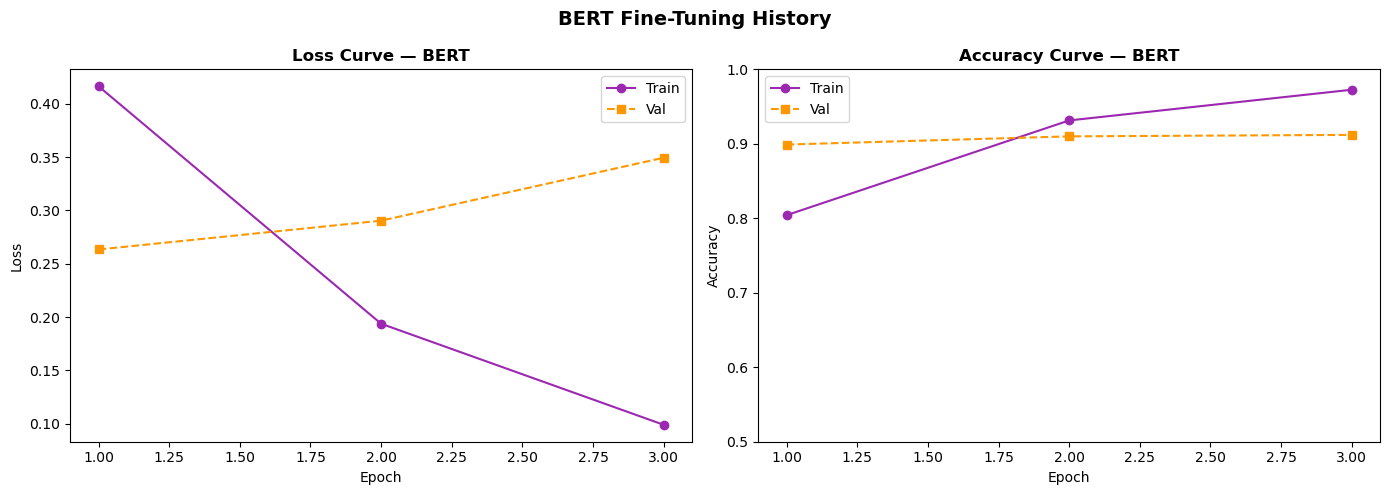

In [14]:
epochs_range = range(1, CONFIG['epochs'] + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history['train_loss'], 'o-', label='Train', color='#9C27B0')
axes[0].plot(epochs_range, history['val_loss'],   's--', label='Val',  color='#FF9800')
axes[0].set_title('Loss Curve — BERT', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs_range, history['train_acc'], 'o-', label='Train', color='#9C27B0')
axes[1].plot(epochs_range, history['val_acc'],   's--', label='Val',  color='#FF9800')
axes[1].set_title('Accuracy Curve — BERT', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.5, 1.0)
axes[1].legend()

plt.suptitle('BERT Fine-Tuning History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bert_training_curves.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 9. Evaluation on Test Set

In [15]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)

        probs = model(input_ids, attention_mask).cpu().numpy()
        preds = (probs >= 0.5).astype(int)

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(batch['label'].numpy().astype(int))

print('=== Classification Report — BERT ===')
print(classification_report(all_labels, all_preds, target_names=['Negative', 'Positive']))
print(f'ROC-AUC Score: {roc_auc_score(all_labels, all_probs):.4f}')

=== Classification Report — BERT ===
              precision    recall  f1-score   support

    Negative       0.91      0.92      0.91       511
    Positive       0.91      0.91      0.91       489

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000

ROC-AUC Score: 0.9678


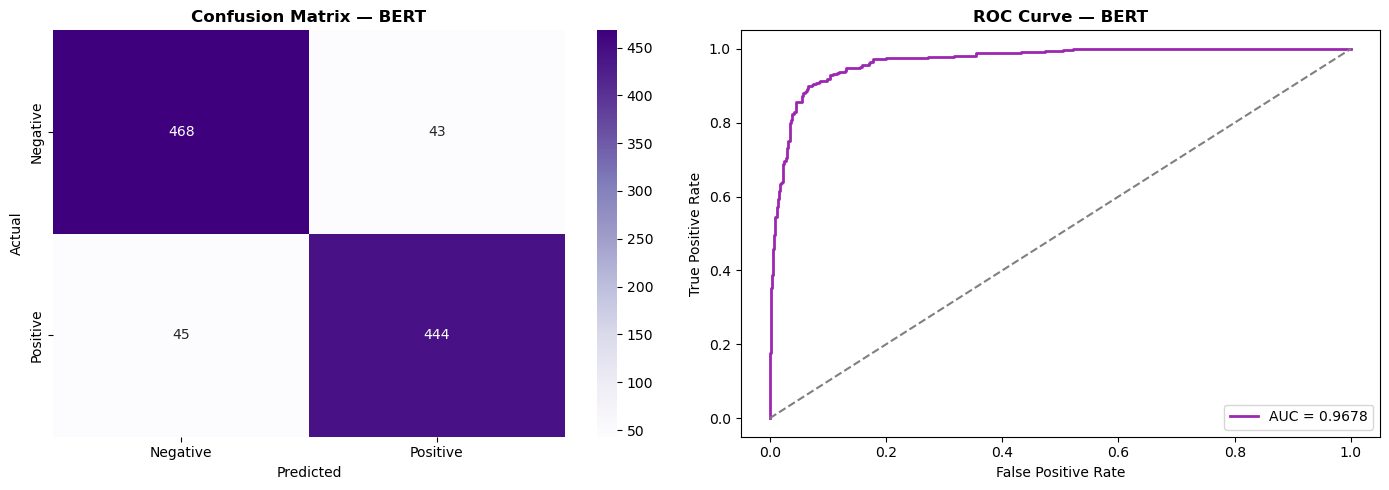

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Purples',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix — BERT', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
auc_score   = roc_auc_score(all_labels, all_probs)
axes[1].plot(fpr, tpr, color='#9C27B0', lw=2, label=f'AUC = {auc_score:.4f}')
axes[1].plot([0, 1], [0, 1], color='grey', linestyle='--')
axes[1].set_title('ROC Curve — BERT', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.savefig('bert_evaluation.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 10. Head-to-Head Comparison: LSTM vs BERT

In [17]:
# ── LSTM results from notebook 02 ──────────────────────────────
lstm_results = {
    'Accuracy' : 0.8046,
    'ROC-AUC'  : 0.8859,
    'Neg F1'   : 0.78,
    'Pos F1'   : 0.82,
}

bert_acc = accuracy_score(all_labels, all_preds)
bert_auc = roc_auc_score(all_labels, all_probs)
from sklearn.metrics import f1_score
bert_neg_f1 = f1_score(all_labels, all_preds, pos_label=0)
bert_pos_f1 = f1_score(all_labels, all_preds, pos_label=1)

bert_results = {
    'Accuracy' : round(bert_acc, 4),
    'ROC-AUC'  : round(bert_auc, 4),
    'Neg F1'   : round(bert_neg_f1, 2),
    'Pos F1'   : round(bert_pos_f1, 2),
}

# ── Print comparison table ───────────────────────────────────────────────────
print('╔══════════════╦══════════════╦══════════════╗')
print('║    Metric    ║   BiLSTM     ║     BERT     ║')
print('╠══════════════╬══════════════╬══════════════╣')
for metric in ['Accuracy', 'ROC-AUC', 'Neg F1', 'Pos F1']:
    lstm_val = lstm_results[metric]
    bert_val = bert_results[metric]
    winner = '🏆' if bert_val > lstm_val else '  '
    print(f'║ {metric:<12} ║ {lstm_val:<12} ║ {bert_val:<10} {winner} ║')
print('╚══════════════╩══════════════╩══════════════╝')

╔══════════════╦══════════════╦══════════════╗
║    Metric    ║   BiLSTM     ║     BERT     ║
╠══════════════╬══════════════╬══════════════╣
║ Accuracy     ║ 0.8046       ║ 0.912      🏆 ║
║ ROC-AUC      ║ 0.8859       ║ 0.9678     🏆 ║
║ Neg F1       ║ 0.78         ║ 0.91       🏆 ║
║ Pos F1       ║ 0.82         ║ 0.91       🏆 ║
╚══════════════╩══════════════╩══════════════╝


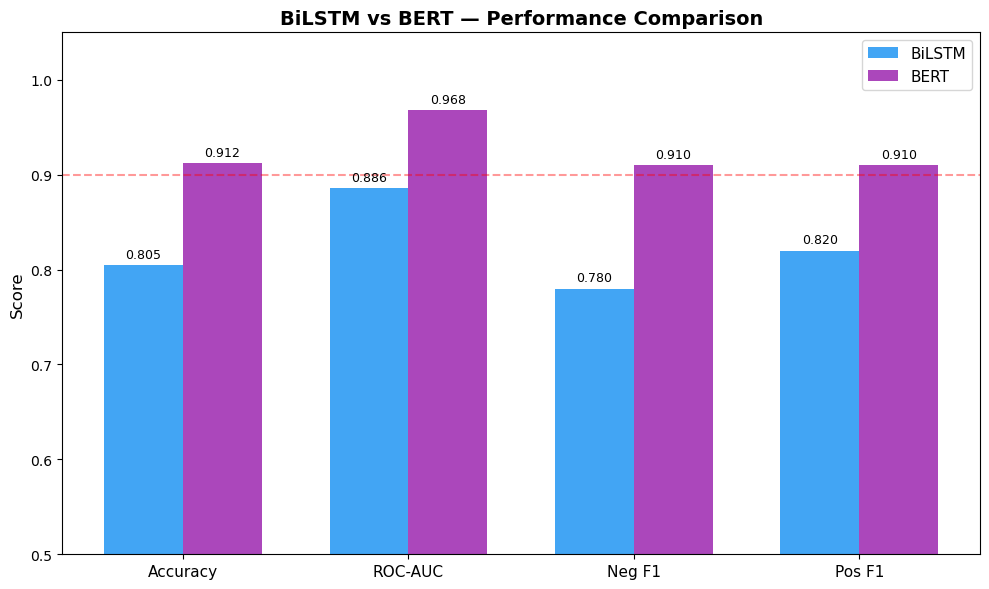

In [18]:
# ── Visual comparison bar chart ──────────────────────────────────────────────
metrics = ['Accuracy', 'ROC-AUC', 'Neg F1', 'Pos F1']
lstm_vals = [lstm_results[m] for m in metrics]
bert_vals = [bert_results[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, lstm_vals, width, label='BiLSTM', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + width/2, bert_vals, width, label='BERT',   color='#9C27B0', alpha=0.85)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('BiLSTM vs BERT — Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.5, 1.05)
ax.legend(fontsize=11)
ax.bar_label(bars1, padding=3, fmt='%.3f', fontsize=9)
ax.bar_label(bars2, padding=3, fmt='%.3f', fontsize=9)
ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.4, label='0.90 baseline')

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 11. Inference — Try Your Own Review

In [21]:
def predict_bert(text, model, tokenizer, max_len, device):
    model.eval()
    encoding = tokenizer(
        text,
        max_length     = max_len,
        padding        = 'max_length',
        truncation     = True,
        return_tensors = 'pt'
    )
    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        prob = model(input_ids, attention_mask).item()

    label = 'Positive 😊' if prob >= 0.5 else 'Negative 😞'
    conf  = prob if prob >= 0.5 else 1 - prob
    return label, round(conf * 100, 2)


samples = [
    "This movie was absolutely brilliant! The acting was superb and the story kept me engaged throughout.",
    "Terrible waste of time. The plot made no sense and the characters were completely flat.",
    "It was okay. Some good moments but overall a bit disappointing.",
    "It was so boring. Save your bucks!",
    "Im hooked!",
    "Bruh it was mid."
]

print('=== BERT Inference ===')
for s in samples:
    label, conf = predict_bert(s, model, tokenizer, CONFIG['max_len'], DEVICE)
    print(f'Review : {s[:70]}...')
    print(f'Result : {label} (confidence: {conf}%)')
    print()

=== BERT Inference ===
Review : This movie was absolutely brilliant! The acting was superb and the sto...
Result : Positive 😊 (confidence: 99.49%)

Review : Terrible waste of time. The plot made no sense and the characters were...
Result : Negative 😞 (confidence: 99.41%)

Review : It was okay. Some good moments but overall a bit disappointing....
Result : Negative 😞 (confidence: 95.72%)

Review : It was so boring. Save your bucks!...
Result : Negative 😞 (confidence: 98.17%)

Review : Im hooked!...
Result : Positive 😊 (confidence: 81.62%)

Review : Bruh it was mid....
Result : Negative 😞 (confidence: 70.2%)



---
## 12. Push BERT Model to HuggingFace Hub

> This saves your fine-tuned model to HuggingFace Hub so the Gradio app can load it from anywhere — no need to bundle large weights in the Spaces repo.

In [24]:
import getpass
from huggingface_hub import login

token = getpass.getpass("Enter HuggingFace token: ")
login(token=token)

Enter HuggingFace token:  ········


In [25]:
# Step 2: Save model + tokenizer locally
os.makedirs('models/bert_sentiment', exist_ok=True)

# Save the fine-tuned BERT weights inside the HuggingFace model wrapper
model.bert.save_pretrained('models/bert_sentiment')
tokenizer.save_pretrained('models/bert_sentiment')

# Also save classifier head weights separately
torch.save({
    'classifier_state_dict': model.classifier.state_dict(),
    'dropout'              : CONFIG['dropout'],
    'max_len'              : CONFIG['max_len'],
}, 'models/bert_sentiment/classifier_head.pt')

print('✅ Model saved to models/bert_sentiment/')

✅ Model saved to models/bert_sentiment/


In [27]:
HF_USERNAME = 'yxnmei'          
REPO_NAME   = 'imdb-bert-sentiment'

from huggingface_hub import HfApi
api = HfApi()

api.create_repo(repo_id=f'{HF_USERNAME}/{REPO_NAME}', exist_ok=True)
api.upload_folder(
    folder_path = 'models/bert_sentiment',
    repo_id     = f'{HF_USERNAME}/{REPO_NAME}',
    repo_type   = 'model'
)

print(f'✅ Model pushed to: https://huggingface.co/{HF_USERNAME}/{REPO_NAME}')

Upload 0 LFS files: 0it [00:00, ?it/s]

No files have been modified since last commit. Skipping to prevent empty commit.


✅ Model pushed to: https://huggingface.co/yxnmei/imdb-bert-sentiment


---
## 13. Final Summary

| | BiLSTM | BERT |
|---|---|---|
| **Pretrained?** | ❌ Trained from scratch | ✅ Pretrained on 3.3B words |
| **Epochs needed** | 5–10 | 2–3 |
| **Parameters** | ~5.4M | ~110M |
| **Tokenization** | Simple word split | WordPiece subword |
| **Context** | Sequential (BiLSTM) | Global self-attention |
| **Expected Accuracy** | ~80–88% | ~93–94% |

**Key takeaway for your portfolio:**  
> *"BERT achieves higher accuracy in fewer epochs by leveraging transfer learning — demonstrating the real-world trade-off between model complexity, compute cost, and performance. For production systems, BERT's accuracy gain justifies the compute cost for high-stakes decisions, while a BiLSTM may suffice for latency-sensitive applications."*

➡️ **Next:** `app.py` — Build the Gradio demo and deploy to HuggingFace Spaces!